In [1]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer
import torch

model_path = "./best_model_1000"  # or wherever you saved your model

# Load tokenizer and model
tokenizer = AutoTokenizer.from_pretrained(model_path)
model = AutoModelForSequenceClassification.from_pretrained(model_path)

# Move model to appropriate device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)
model.eval()

print(f"Model loaded from {model_path}")
print(f"Using device: {device}")

/home/hussam/python_envs/complete_venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 201/201 [00:00<00:00, 778.14it/s, Materializing param=classifier.weight]                                      


Model loaded from ./best_model_1000
Using device: cpu


In [2]:
import pandas as pd
import json

# Load your events data (assuming you have the JSON from previous responses)
with open('../datasets/events_dataset_v2.json', 'r', encoding='utf-8') as f:
    events = json.load(f)

# Create a DataFrame
df = pd.DataFrame(events)

# Display class distribution
print(df['era'].value_counts())

# Example structure:
# - text: event description + event name (input)
# - label: era (target)
df['text'] = df['event_name'] + " - " + df['description']

era
حقبة الدول المغاربية    211
حقبة الخلافة الأموية    206
حقبة النشأة             203
حقبة ملوك الطوائف       198
حقبة مملكة غرناطة       174
Name: count, dtype: int64


In [23]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
df['label'] = label_encoder.fit_transform(df['era'])

# Save label mapping for later use
label_mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
# with open('../datasets/events_dataset1.json', 'w', encoding='utf-8') as f:
#     json.dump(label_mapping, f, ensure_ascii=True, indent=2)

In [4]:
# input_ids = batch['input_ids'].to(device)
# attention_mask = batch['attention_mask'].to(device)
# labels = batch['labels'].to(device)
text = "رحيل بوعبديل "
# Forward pass
encoding = tokenizer(
            text,
            truncation=True,
            padding='max_length',
            max_length=512,
            return_tensors='pt'
        )
# tokenizer.tokenize()
# outputs = model(encoding)
encoding
input_ids = encoding['input_ids'].to(device)
attention_mask = encoding['attention_mask'].to(device)
# labels = encoding['labels'].to(device)

# Forward pass
outputs = model(input_ids=input_ids, attention_mask=attention_mask)
logits = outputs.logits
probs = torch.nn.functional.softmax(logits, dim=-1)
predictions = torch.argmax(logits, dim=-1)

In [5]:
labels = { 0:'حقبة الخلافة الأموية',
 1:'حقبة الدول المغاربية',
 2:'حقبة النشأة',
 3:'حقبة ملوك الطوائف',
 4:'حقبة مملكة غرناطة'}

In [6]:
print(probs.tolist())
print(labels[predictions.tolist()[0]])

[[0.016206888481974602, 0.005710459314286709, 0.020601363852620125, 0.11104939877986908, 0.8464318513870239]]
حقبة مملكة غرناطة


In [7]:
counter = 0
for text in df["text"][:100]:
    
    # Forward pass
    encoding = tokenizer(
                text,
                truncation=True,
                padding='max_length',
                max_length=512,
                return_tensors='pt'
            )
    # tokenizer.tokenize()
    # outputs = model(encoding)
    encoding
    input_ids = encoding['input_ids'].to(device)
    attention_mask = encoding['attention_mask'].to(device)
    # labels = encoding['labels'].to(device)

    # Forward pass
    outputs = model(input_ids=input_ids, attention_mask=attention_mask)
    logits = outputs.logits
    probs = torch.nn.functional.softmax(logits, dim=-1)
    predictions = torch.argmax(logits, dim=-1)
    print("truth: ",df["era"][counter])
    print("predi: ", labels[predictions.tolist()[0]])
    print("----------------------------------------")
    counter+=1
    

truth:  حقبة النشأة
predi:  حقبة الخلافة الأموية
----------------------------------------
truth:  حقبة الخلافة الأموية
predi:  حقبة الخلافة الأموية
----------------------------------------
truth:  حقبة الخلافة الأموية
predi:  حقبة الدول المغاربية
----------------------------------------
truth:  حقبة الخلافة الأموية
predi:  حقبة الدول المغاربية
----------------------------------------
truth:  حقبة الخلافة الأموية
predi:  حقبة الخلافة الأموية
----------------------------------------
truth:  حقبة الخلافة الأموية
predi:  حقبة الخلافة الأموية
----------------------------------------
truth:  حقبة الخلافة الأموية
predi:  حقبة الخلافة الأموية
----------------------------------------
truth:  حقبة ملوك الطوائف
predi:  حقبة ملوك الطوائف
----------------------------------------
truth:  حقبة ملوك الطوائف
predi:  حقبة ملوك الطوائف
----------------------------------------
truth:  حقبة ملوك الطوائف
predi:  حقبة ملوك الطوائف
----------------------------------------
truth:  حقبة ملوك الطوائف
predi:  حقب

In [8]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from torch.utils.data import DataLoader

# Assuming you have a test dataset and dataloader
# test_dataset = YourTestDataset()
# test_loader = DataLoader(test_dataset, batch_size=32)

def plot_confusion_matrix(model, test_loader, device, class_names=None):
    """
    Plot confusion matrix for model predictions on test data
    
    Args:
        model: Your trained model
        test_loader: DataLoader for test dataset
        device: Device (cuda/cpu)
        class_names: List of class names (optional)
    """
    model.eval()
    all_predictions = []
    all_labels = []
    
    with torch.no_grad():
        for batch in test_loader:
            # Move data to device
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)
            
            # Forward pass
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            logits = outputs.logits
            predictions = torch.argmax(logits, dim=-1)
            
            # Collect predictions and labels
            all_predictions.extend(predictions.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    # Convert to numpy arrays
    all_predictions = np.array(all_predictions)
    all_labels = np.array(all_labels)
    
    # Create confusion matrix
    cm = confusion_matrix(all_labels, all_predictions)
    
    # Plot confusion matrix
    if class_names is None:
        # If class names not provided, use numbers
        class_names = [str(i) for i in range(cm.shape[0])]
    
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    
    fig, ax = plt.subplots(figsize=(10, 10))
    disp.plot(ax=ax, cmap='Blues', values_format='d')
    
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.tight_layout()
    
    return fig, cm

# Alternative: If you want to use matplotlib directly
def plot_confusion_matrix_simple(all_labels, all_predictions, class_names=None):
    """
    Simple confusion matrix plot using matplotlib
    """
    # Compute confusion matrix
    cm = confusion_matrix(all_labels, all_predictions)
    
    if class_names is None:
        class_names = [str(i) for i in range(cm.shape[0])]
    
    # Plot
    fig, ax = plt.subplots(figsize=(10, 10))
    
    # Create heatmap
    im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    ax.figure.colorbar(im, ax=ax)
    
    # Show all ticks
    ax.set(xticks=np.arange(cm.shape[1]),
           yticks=np.arange(cm.shape[0]),
           xticklabels=class_names,
           yticklabels=class_names,
           title='Confusion Matrix',
           ylabel='True Label',
           xlabel='Predicted Label')
    
    # Rotate the tick labels
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
    
    # Loop over data dimensions and create text annotations
    fmt = 'd'
    thresh = cm.max() / 2.
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, format(cm[i, j], fmt),
                    ha="center", va="center",
                    color="white" if cm[i, j] > thresh else "black")
    
    fig.tight_layout()
    return fig, cm

# For your single text prediction example:
# If you want to get predictions for multiple samples, you can do:

def predict_multiple_texts(model, tokenizer, texts, device, true_labels=None):
    """
    Make predictions on multiple texts
    
    Args:
        model: Your trained model
        tokenizer: Tokenizer
        texts: List of texts to predict
        device: Device (cuda/cpu)
        true_labels: Optional list of true labels
    """
    model.eval()
    predictions = []
    
    with torch.no_grad():
        for text in texts:
            # Tokenize
            encoding = tokenizer(
                text,
                truncation=True,
                padding='max_length',
                max_length=512,
                return_tensors='pt'
            )
            
            input_ids = encoding['input_ids'].to(device)
            attention_mask = encoding['attention_mask'].to(device)
            
            # Forward pass
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            logits = outputs.logits
            pred = torch.argmax(logits, dim=-1).cpu().numpy()[0]
            predictions.append(pred)
    
    if true_labels is not None:
        # Plot confusion matrix
        fig, cm = plot_confusion_matrix_simple(true_labels, predictions)
        plt.show()
        
        # Print classification report
        from sklearn.metrics import classification_report
        print("\nClassification Report:")
        print(classification_report(true_labels, predictions))
    
    return predictions

# Usage example:
"""
# Assuming you have:
# - A trained model
# - A test dataset with labels

# Method 1: Using test loader
# fig, cm = plot_confusion_matrix(model, test_loader, device)
plt.show()

# Method 2: If you have lists of texts and labels
texts = ["text1", "text2", "text3", ...]
true_labels = [0, 1, 2, ...]  # Your true labels

predictions = predict_multiple_texts(model, tokenizer, texts, device, true_labels)

# Method 3: If you want to save the confusion matrix
fig, cm = plot_confusion_matrix(model, test_loader, device)
plt.savefig('confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

# Print metrics
print("Confusion Matrix:")
print(cm)

# Calculate metrics
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

accuracy = accuracy_score(all_labels, all_predictions)
precision, recall, f1, _ = precision_recall_fscore_support(all_labels, all_predictions, average='weighted')

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")
"""

'\n# Assuming you have:\n# - A trained model\n# - A test dataset with labels\n\n# Method 1: Using test loader\n# fig, cm = plot_confusion_matrix(model, test_loader, device)\nplt.show()\n\n# Method 2: If you have lists of texts and labels\ntexts = ["text1", "text2", "text3", ...]\ntrue_labels = [0, 1, 2, ...]  # Your true labels\n\npredictions = predict_multiple_texts(model, tokenizer, texts, device, true_labels)\n\n# Method 3: If you want to save the confusion matrix\nfig, cm = plot_confusion_matrix(model, test_loader, device)\nplt.savefig(\'confusion_matrix.png\', dpi=300, bbox_inches=\'tight\')\nplt.show()\n\n# Print metrics\nprint("Confusion Matrix:")\nprint(cm)\n\n# Calculate metrics\nfrom sklearn.metrics import accuracy_score, precision_recall_fscore_support\n\naccuracy = accuracy_score(all_labels, all_predictions)\nprecision, recall, f1, _ = precision_recall_fscore_support(all_labels, all_predictions, average=\'weighted\')\n\nprint(f"Accuracy: {accuracy:.4f}")\nprint(f"Precision:

In [20]:
df["era"]

0               حقبة النشأة
1      حقبة الخلافة الأموية
2      حقبة الخلافة الأموية
3      حقبة الخلافة الأموية
4      حقبة الخلافة الأموية
               ...         
987       حقبة مملكة غرناطة
988       حقبة مملكة غرناطة
989       حقبة مملكة غرناطة
990       حقبة مملكة غرناطة
991       حقبة مملكة غرناطة
Name: era, Length: 992, dtype: object

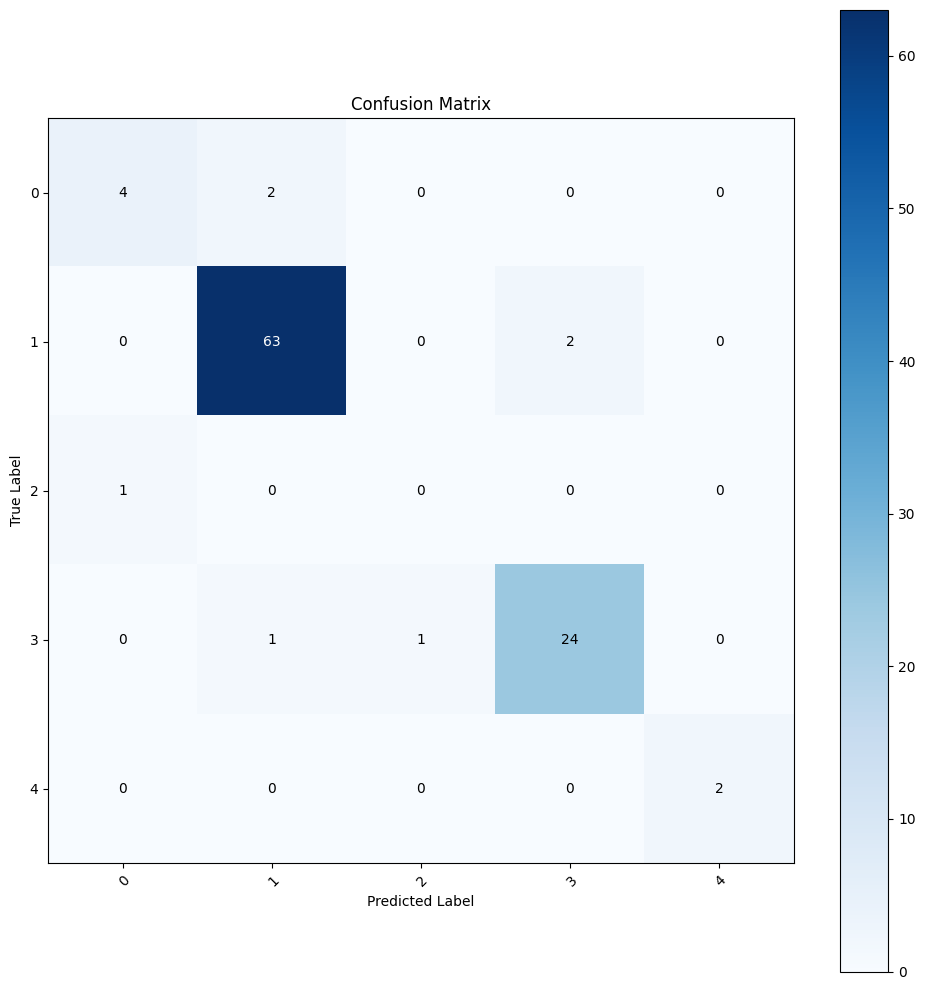


Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.67      0.73         6
           1       0.95      0.97      0.96        65
           2       0.00      0.00      0.00         1
           3       0.92      0.92      0.92        26
           4       1.00      1.00      1.00         2

    accuracy                           0.93       100
   macro avg       0.74      0.71      0.72       100
weighted avg       0.93      0.93      0.93       100



In [25]:
# print("truth: ",df["era"][counter])
# print("predi: ", labels[predictions.tolist()[0]])

texts = df["text"][:100]
true_labels = df["label"][:100]  # Your true labels

predictions = predict_multiple_texts(model, tokenizer, texts, device, true_labels)